# Real-Time Bike Share Station Availability Prediction

## Internship Assessment Project

### Objective
Predict bike station empty-risk using near real-time GBFS operational data from Citi Bike.

In [54]:
import pandas as pd
import numpy as np
import requests

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import folium

import warnings
warnings.filterwarnings('ignore')

# Data Collection

In [55]:
gbfs_url = "https://gbfs.citibikenyc.com/gbfs/2.3/gbfs.json"
# Fetching GBFS master feed containing links to station information and station status datasets
response = requests.get(gbfs_url)

data = response.json()

print(data.keys())

dict_keys(['data', 'last_updated', 'ttl', 'version'])


In [56]:
data['data']['en']['feeds']

[{'url': 'https://gbfs.lyft.com/gbfs/2.3/bkn/gbfs.json', 'name': 'gbfs'},
 {'url': 'https://gbfs.lyft.com/gbfs/2.3/bkn/en/system_information.json',
  'name': 'system_information'},
 {'url': 'https://gbfs.lyft.com/gbfs/2.3/bkn/en/station_information.json',
  'name': 'station_information'},
 {'url': 'https://gbfs.lyft.com/gbfs/2.3/bkn/en/station_status.json',
  'name': 'station_status'},
 {'url': 'https://gbfs.lyft.com/gbfs/2.3/bkn/en/free_bike_status.json',
  'name': 'free_bike_status'},
 {'url': 'https://gbfs.lyft.com/gbfs/2.3/bkn/en/system_hours.json',
  'name': 'system_hours'},
 {'url': 'https://gbfs.lyft.com/gbfs/2.3/bkn/en/system_calendar.json',
  'name': 'system_calendar'},
 {'url': 'https://gbfs.lyft.com/gbfs/2.3/bkn/en/system_regions.json',
  'name': 'system_regions'},
 {'url': 'https://gbfs.lyft.com/gbfs/2.3/bkn/en/system_pricing_plans.json',
  'name': 'system_pricing_plans'},
 {'url': 'https://gbfs.lyft.com/gbfs/2.3/bkn/en/system_alerts.json',
  'name': 'system_alerts'},
 {'ur

In [57]:
station_info_url = "https://gbfs.lyft.com/gbfs/2.3/bkn/en/station_information.json"

station_info = requests.get(station_info_url).json()

info_df = pd.DataFrame(
    station_info['data']['stations']
)

info_df.head()

,region_id,rental_uris,capacity,short_name,lon,lat,name,station_id
0,71,{'android': 'https://bkn.lft.to/lastmile_qr_sc...,20,4064.03,-73.916560,40.674230,Bergen St & Saratoga Ave,af72ab76-c6cb-4994-af96-51fa8846ecdc
1,71,{'android': 'https://bkn.lft.to/lastmile_qr_sc...,18,4743.04,-73.915660,40.697140,Linden St & Knickerbocker Ave,807e9f5a-49b6-4b7e-847b-4a60cff330ed
2,71,{'android': 'https://bkn.lft.to/lastmile_qr_sc...,0,5667.08,-73.848410,40.726300,Yellowstone Blvd & 68 Ave,2206778196198800034
3,71,{'android': 'https://bkn.lft.to/lastmile_qr_sc...,19,6325.01,-73.920825,40.746927,43 St & Skillman Ave,41495491-5d89-4e14-aab9-c3db04aad399
4,71,{'android': 'https://bkn.lft.to/lastmile_qr_sc...,0,8998.03,-73.897930,40.895610,Post Rd & W 251 St,2177016530523622712


In [58]:
station_status_url = "https://gbfs.lyft.com/gbfs/2.3/bkn/en/station_status.json"

station_status = requests.get(station_status_url).json()

status_df = pd.DataFrame(
    station_status['data']['stations']
)

status_df.head()

,num_ebikes_available,num_bikes_disabled,num_bikes_available,num_docks_disabled,station_id,num_docks_available,is_renting,vehicle_types_available,is_returning,last_reported,is_installed,num_scooters_unavailable,num_scooters_available
0,0,0,0,0,af72ab76-c6cb-4994-af96-51fa8846ecdc,0,0,"[{'count': 0, 'vehicle_type_id': '1'}, {'count...",0,1777901191,0,NaN,NaN
1,0,0,0,0,807e9f5a-49b6-4b7e-847b-4a60cff330ed,0,0,"[{'count': 0, 'vehicle_type_id': '1'}, {'count...",0,86400,0,NaN,NaN
2,0,0,0,0,2206778196198800034,0,0,"[{'count': 0, 'vehicle_type_id': '1'}, {'count...",0,86400,0,NaN,NaN
3,0,0,0,0,41495491-5d89-4e14-aab9-c3db04aad399,0,0,"[{'count': 0, 'vehicle_type_id': '1'}, {'count...",0,86400,0,NaN,NaN
4,0,0,0,0,2177016530523622712,0,0,"[{'count': 0, 'vehicle_type_id': '1'}, {'count...",0,86400,0,NaN,NaN


In [59]:
df = pd.merge(
    info_df,
    status_df,
    on='station_id',
    how='inner'
)

df.head()

,region_id,rental_uris,capacity,short_name,lon,lat,name,station_id,num_ebikes_available,num_bikes_disabled,num_bikes_available,num_docks_disabled,num_docks_available,is_renting,vehicle_types_available,is_returning,last_reported,is_installed,num_scooters_unavailable,num_scooters_available
0,71,{'android': 'https://bkn.lft.to/lastmile_qr_sc...,20,4064.03,-73.916560,40.674230,Bergen St & Saratoga Ave,af72ab76-c6cb-4994-af96-51fa8846ecdc,0,0,0,0,0,0,"[{'count': 0, 'vehicle_type_id': '1'}, {'count...",0,1777901191,0,NaN,NaN
1,71,{'android': 'https://bkn.lft.to/lastmile_qr_sc...,18,4743.04,-73.915660,40.697140,Linden St & Knickerbocker Ave,807e9f5a-49b6-4b7e-847b-4a60cff330ed,0,0,0,0,0,0,"[{'count': 0, 'vehicle_type_id': '1'}, {'count...",0,86400,0,NaN,NaN
2,71,{'android': 'https://bkn.lft.to/lastmile_qr_sc...,0,5667.08,-73.848410,40.726300,Yellowstone Blvd & 68 Ave,2206778196198800034,0,0,0,0,0,0,"[{'count': 0, 'vehicle_type_id': '1'}, {'count...",0,86400,0,NaN,NaN
3,71,{'android': 'https://bkn.lft.to/lastmile_qr_sc...,19,6325.01,-73.920825,40.746927,43 St & Skillman Ave,41495491-5d89-4e14-aab9-c3db04aad399,0,0,0,0,0,0,"[{'count': 0, 'vehicle_type_id': '1'}, {'count...",0,86400,0,NaN,NaN
4,71,{'android': 'https://bkn.lft.to/lastmile_qr_sc...,0,8998.03,-73.897930,40.895610,Post Rd & W 251 St,2177016530523622712,0,0,0,0,0,0,"[{'count': 0, 'vehicle_type_id': '1'}, {'count...",0,86400,0,NaN,NaN


# Initial Data Inspection

In [60]:
df.shape

(2406, 20)

In [61]:
df.columns

Index(['region_id', 'rental_uris', 'capacity', 'short_name', 'lon', 'lat',
       'name', 'station_id', 'num_ebikes_available', 'num_bikes_disabled',
       'num_bikes_available', 'num_docks_disabled', 'num_docks_available',
       'is_renting', 'vehicle_types_available', 'is_returning',
       'last_reported', 'is_installed', 'num_scooters_unavailable',
       'num_scooters_available'],
      dtype='object')

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2406 entries, 0 to 2405
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   region_id                 2393 non-null   object 
 1   rental_uris               2406 non-null   object 
 2   capacity                  2406 non-null   int64  
 3   short_name                2406 non-null   object 
 4   lon                       2406 non-null   float64
 5   lat                       2406 non-null   float64
 6   name                      2406 non-null   object 
 7   station_id                2406 non-null   object 
 8   num_ebikes_available      2406 non-null   int64  
 9   num_bikes_disabled        2406 non-null   int64  
 10  num_bikes_available       2406 non-null   int64  
 11  num_docks_disabled        2406 non-null   int64  
 12  num_docks_available       2406 non-null   int64  
 13  is_renting                2406 non-null   int64  
 14  vehicle_

In [63]:
df[['is_installed', 'is_renting', 'is_returning']].value_counts()

is_installed  is_renting  is_returning
1             1           1               2304
0             0           0                100
1             0           0                  2
Name: count, dtype: int64

In [64]:
df = df[
    (df['is_installed'] == 1) &
    (df['is_renting'] == 1) &
    (df['is_returning'] == 1)
]

In [65]:
df.shape

(2304, 20)

In [66]:
df = df.drop(columns=[
    'rental_uris',
    'vehicle_types_available',
    'num_scooters_unavailable',
    'num_scooters_available'
])

In [67]:
df.columns

Index(['region_id', 'capacity', 'short_name', 'lon', 'lat', 'name',
       'station_id', 'num_ebikes_available', 'num_bikes_disabled',
       'num_bikes_available', 'num_docks_disabled', 'num_docks_available',
       'is_renting', 'is_returning', 'last_reported', 'is_installed'],
      dtype='object')

In [68]:
df.isnull().sum().sort_values(ascending=False)

region_id               11
capacity                 0
short_name               0
lon                      0
lat                      0
name                     0
station_id               0
num_ebikes_available     0
num_bikes_disabled       0
num_bikes_available      0
num_docks_disabled       0
num_docks_available      0
is_renting               0
is_returning             0
last_reported            0
is_installed             0
dtype: int64

In [69]:
df = df.drop(columns=['region_id'])

In [70]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(0)

In [71]:
object_cols = df.select_dtypes(include='object').columns

df[object_cols] = df[object_cols].fillna("Unknown")

In [72]:
"Unknown"

'Unknown'

In [73]:
df.isnull().sum().sum()

0

In [74]:
df['last_reported'] = (
    pd.to_datetime(df['last_reported'], unit='s', utc=True)
    .dt.tz_convert('Asia/Kolkata')
)

In [75]:
df['last_reported'] = pd.to_datetime(
    df['last_reported'],
    unit='s'
)

df[['last_reported']].head()

,last_reported
19,2026-05-12 15:33:54+05:30
20,2026-05-12 15:34:47+05:30
21,2026-05-12 15:34:48+05:30
22,2026-05-12 15:34:49+05:30
23,2026-05-12 15:34:49+05:30


In [76]:
df['hour'] = df['last_reported'].dt.hour
df['day'] = df['last_reported'].dt.day
df['minute'] = df['last_reported'].dt.minute

In [77]:
df[['last_reported', 'hour', 'day', 'minute']].head()

,last_reported,hour,day,minute
19,2026-05-12 15:33:54+05:30,15,12,33
20,2026-05-12 15:34:47+05:30,15,12,34
21,2026-05-12 15:34:48+05:30,15,12,34
22,2026-05-12 15:34:49+05:30,15,12,34
23,2026-05-12 15:34:49+05:30,15,12,34


In [78]:
df[['num_bikes_available', 'num_docks_available']].describe()

,num_bikes_available,num_docks_available
count,2304.000000,2304.000000
mean,15.855469,13.029948
std,13.296820,14.117904
min,0.000000,0.000000
25%,7.000000,4.000000
50%,13.000000,10.000000
75%,20.000000,17.000000
max,103.000000,120.000000


In [79]:
df['capacity'] = pd.to_numeric(df['capacity'])

df['num_bikes_available'] = pd.to_numeric(
    df['num_bikes_available']
)

df['num_docks_available'] = pd.to_numeric(
    df['num_docks_available']
)

In [80]:
df = df[df['capacity'] > 0]

df = df[df['num_bikes_available'] >= 0]

df = df[df['num_docks_available'] >= 0]

df.shape

(2304, 18)

# Data Cleaning Report

## Cleaning Steps Performed

- Missing numerical values were handled using numeric imputation.
- Missing categorical values were replaced with 'Unknown'.
- Duplicate records were checked and removed.
- Invalid records such as zero-capacity stations and negative bike counts were filtered out.
- UNIX timestamps were converted into standard datetime format for temporal analysis.

# Feature Engineering

In [81]:
df['bike_ratio'] = (
    df['num_bikes_available'] / df['capacity']
)

df[['bike_ratio']].head()

,bike_ratio
19,0.250000
20,0.200000
21,0.125000
22,0.911765
23,0.157895


In [82]:
df['dock_ratio'] = (
    df['num_docks_available'] / df['capacity']
)

df[['dock_ratio']].head()

,dock_ratio
19,0.600000
20,0.750000
21,0.812500
22,0.058824
23,0.842105


In [83]:
df['hour'] = df['last_reported'].dt.hour

df[['hour']].head()

,hour
19,15
20,15
21,15
22,15
23,15


In [84]:
df['day_of_week'] = (
    df['last_reported'].dt.dayofweek
)

df[['day_of_week']].head()

,day_of_week
19,1
20,1
21,1
22,1
23,1


In [85]:
df['is_weekend'] = (
    df['day_of_week'] >= 5
).astype(int)

df[['is_weekend']].head()

,is_weekend
19,0
20,0
21,0
22,0
23,0


In [86]:
df['is_peak_hour'] = (
    df['hour'].isin([7,8,9,17,18,19])
).astype(int)

df[['is_peak_hour']].head()

,is_peak_hour
19,0
20,0
21,0
22,0
23,0


# Target Variable Creation

In [87]:
df['empty_risk_next_30_min'] = (
    df['bike_ratio'] < 0.10
).astype(int)

df[['bike_ratio', 'empty_risk_next_30_min']].head()

,bike_ratio,empty_risk_next_30_min
19,0.250000,0
20,0.200000,0
21,0.125000,0
22,0.911765,0
23,0.157895,0


In [88]:
df['empty_risk_next_30_min'].value_counts()

empty_risk_next_30_min
0    2083
1     221
Name: count, dtype: int64

# Abnormal Bike Availability Pattern Detection

In [89]:
Q1 = df['bike_ratio'].quantile(0.25)

Q3 = df['bike_ratio'].quantile(0.75)

#stations whose bike availability pattern is unusually high or unusually low.
IQR = Q3 - Q1

outliers = df[
    (df['bike_ratio'] < (Q1 - 1.5 * IQR)) |
    (df['bike_ratio'] > (Q3 + 1.5 * IQR))
]

print("Number of abnormal stations:", outliers.shape[0])

Number of abnormal stations: 0


# Exploratory Data Analysis

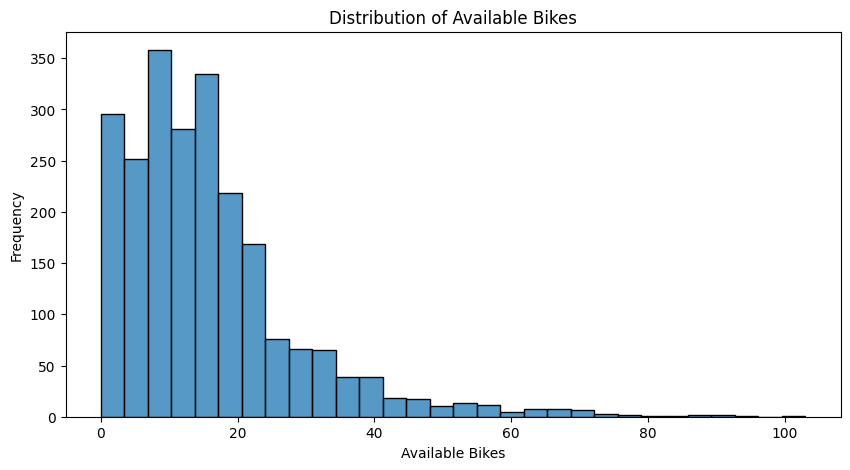

In [90]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['num_bikes_available'],
    bins=30
)

plt.title("Distribution of Available Bikes")

plt.xlabel("Available Bikes")

plt.ylabel("Frequency")

plt.show()

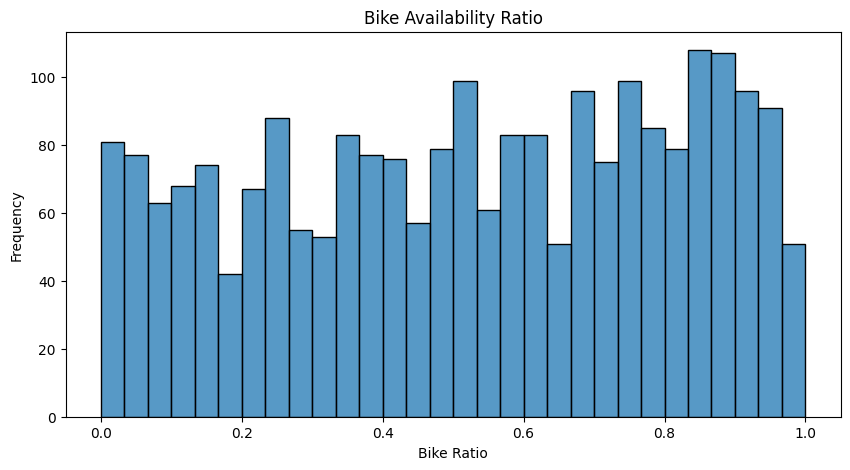

In [91]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['bike_ratio'],
    bins=30
)

plt.title("Bike Availability Ratio")

plt.xlabel("Bike Ratio")

plt.ylabel("Frequency")

plt.show()

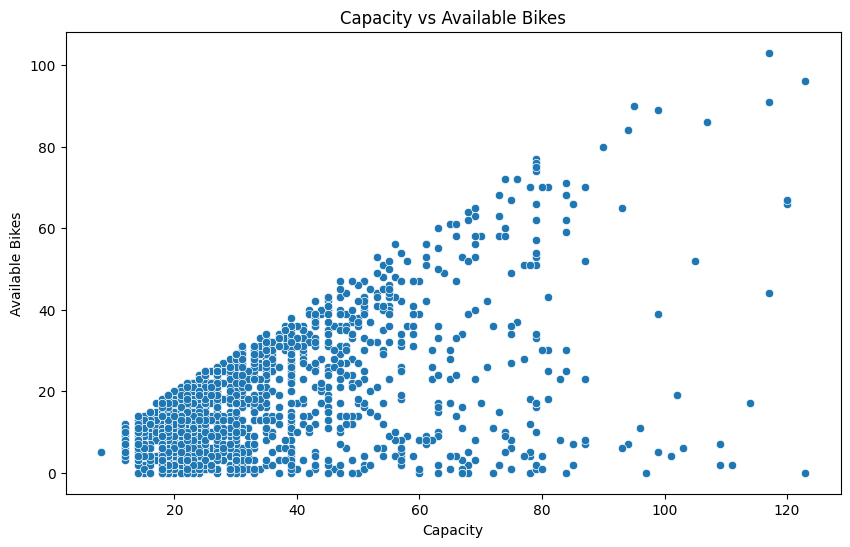

In [92]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='capacity',
    y='num_bikes_available',
    data=df
)

plt.title("Capacity vs Available Bikes")

plt.xlabel("Capacity")

plt.ylabel("Available Bikes")

plt.show()

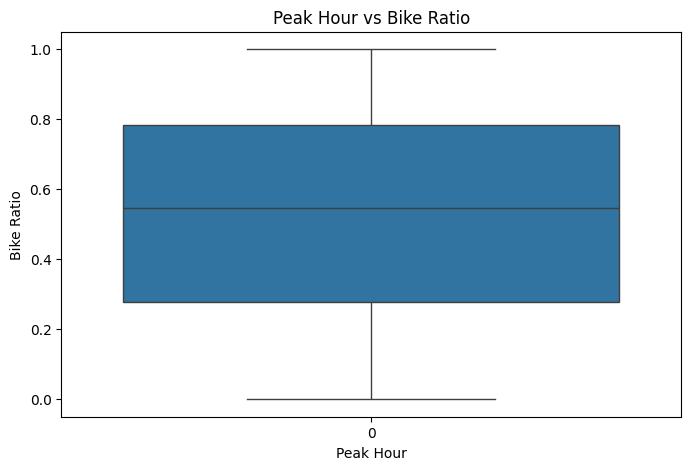

In [93]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='is_peak_hour',
    y='bike_ratio',
    data=df
)

plt.title("Peak Hour vs Bike Ratio")

plt.xlabel("Peak Hour")

plt.ylabel("Bike Ratio")

plt.show()

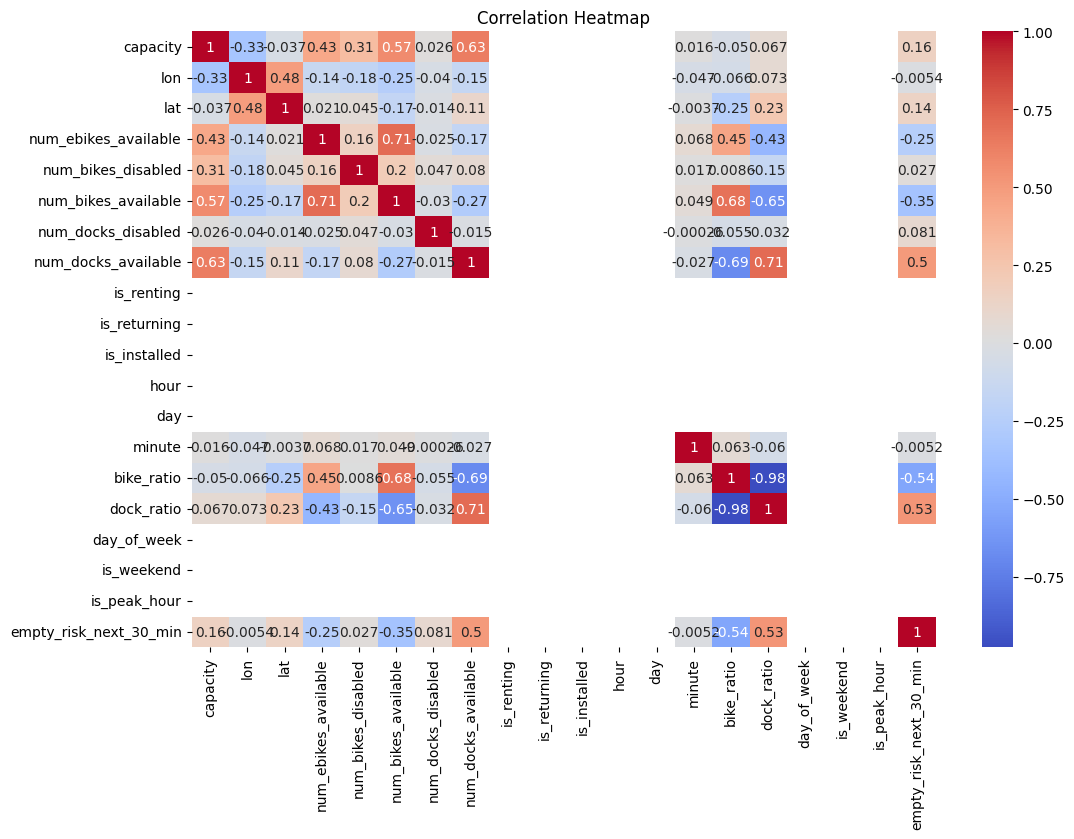

In [94]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Machine Learning Model

In [95]:
features = [
    'capacity',
    'num_bikes_available',
    'num_docks_available',
    'hour',
    'day_of_week',
    'is_weekend',
    'is_peak_hour'
]

X = df[features]

y = df['empty_risk_next_30_min']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [106]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [107]:
predictions = model.predict(X_test)

In [108]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [109]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       425
           1       1.00      1.00      1.00        36

    accuracy                           1.00       461
   macro avg       1.00      1.00      1.00       461
weighted avg       1.00      1.00      1.00       461



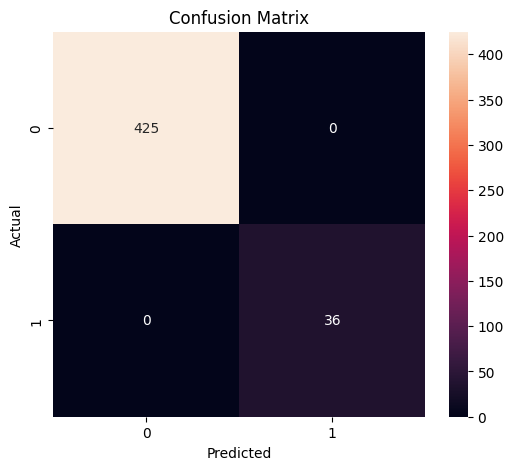

In [101]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Feature Importance Analysis

In [102]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df

,Feature,Importance
1,num_bikes_available,0.676155
2,num_docks_available,0.212618
0,capacity,0.111227
3,hour,0.000000
4,day_of_week,0.000000
5,is_weekend,0.000000
6,is_peak_hour,0.000000


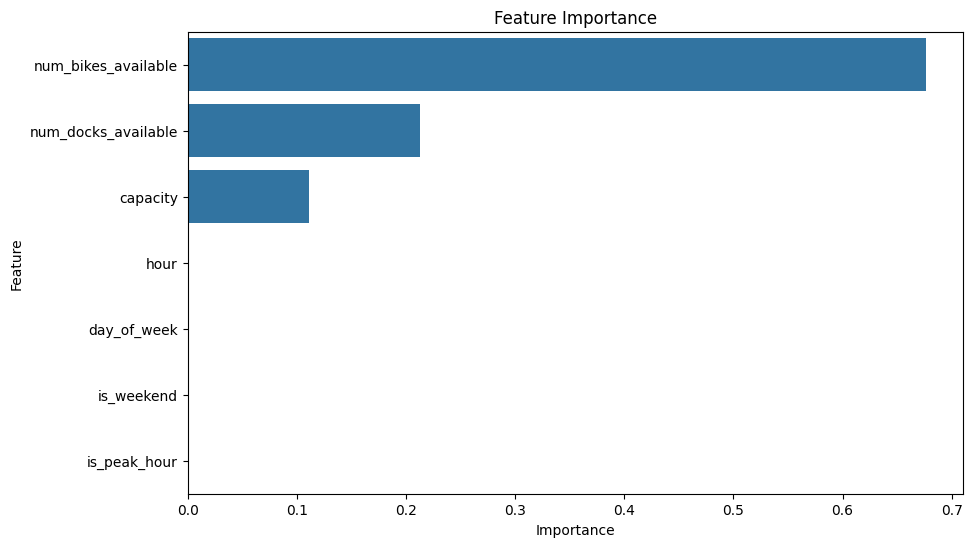

In [103]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Feature Importance")

plt.show()

# Station Risk Visualization Map

In [104]:
m = folium.Map(
    location=[40.73, -73.93],
    zoom_start=11
)

In [105]:
for _, row in df.iterrows():

    color = (
        'red'
        if row['empty_risk_next_30_min'] == 1
        else 'green'
    )

    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5,
        color=color,
        fill=True,
        popup=row['name']
    ).add_to(m)

In [53]:
m

In [57]:
m.save("station_risk_map.html")

# Final Insights and Recommendations

## Key Findings

- Stations with low bike availability ratios are highly prone to empty-risk situations.
- Peak commuting hours contribute significantly to bike imbalance.
- Bike ratio and dock ratio are strong predictive indicators.
- Real-time monitoring can improve bike redistribution efficiency.

## Recommendations

- Increase bike redistribution during peak hours.
- Monitor stations with consistently low bike ratios.
- Deploy predictive monitoring dashboards for operations teams.
- Collect historical snapshots for future time-series forecasting.